# TASK 5 · Autocomplete and Autocorrect Data Analytics

## NLP-Based Text Prediction and Spelling Correction

**Objective:** Analyse the efficiency and accuracy of autocomplete and autocorrect algorithms using NLP techniques. This notebook implements and compares frequency-based n-gram autocomplete models and edit-distance-based spelling correction.

**Tech Stack:** Python, pandas, NLTK, `pyspellchecker`, `collections`, matplotlib, seaborn, Jupyter Notebook.

### Project Workflow
1. Download/load a large text corpus.
2. Perform NLP preprocessing.
3. Build bigram and trigram autocomplete models.
4. Test autocomplete on 10+ prefixes and show top 3 predictions.
5. Implement autocorrect with edit distance using `pyspellchecker`.
6. Test 20 deliberately misspelled words.
7. Calculate Precision, Recall and correction accuracy.
8. Compare two autocomplete approaches.
9. Visualise word frequencies and autocorrection results.
10. Discuss limitations compared with production systems such as Google Keyboard.


## 1. Install / Import Libraries

If the packages are not installed, uncomment the installation command and run it once.

In [2]:

pip install nltk pyspellchecker pandas matplotlib seaborn

   ---------------------------------------- 0.0/7.2 MB ? eta -:--:--
   ------------------ --------------------- 3.4/7.2 MB 24.1 MB/s eta 0:00:01
   -------------------------- ------------- 4.7/7.2 MB 12.6 MB/s eta 0:00:01
   ------------------------------- -------- 5.8/7.2 MB 9.9 MB/s eta 0:00:01
   ---------------------------------- ----- 6.3/7.2 MB 8.7 MB/s eta 0:00:01
   ------------------------------------- -- 6.8/7.2 MB 6.9 MB/s eta 0:00:01
   ---------------------------------------- 7.2/7.2 MB 5.8 MB/s eta 0:00:00
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.0.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [3]:
import re
import random
import warnings
from collections import Counter, defaultdict

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import nltk
from nltk.corpus import gutenberg, stopwords
from nltk.util import ngrams
from nltk.probability import FreqDist

from spellchecker import SpellChecker

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid")

RANDOM_STATE = 42
random.seed(RANDOM_STATE)
np.random.seed(RANDOM_STATE)

print("Libraries imported successfully.")

Libraries imported successfully.


## 2. Download the NLTK Corpus

The **NLTK Gutenberg corpus** contains multiple public-domain books and provides a substantially larger text collection than a small toy sentence dataset.

The notebook downloads the Gutenberg and English stopword resources if they are not already installed.

In [4]:
nltk.download("gutenberg", quiet=True)
nltk.download("stopwords", quiet=True)

print("Gutenberg files available:", len(gutenberg.fileids()))
print(gutenberg.fileids())

Gutenberg files available: 18
['austen-emma.txt', 'austen-persuasion.txt', 'austen-sense.txt', 'bible-kjv.txt', 'blake-poems.txt', 'bryant-stories.txt', 'burgess-busterbrown.txt', 'carroll-alice.txt', 'chesterton-ball.txt', 'chesterton-brown.txt', 'chesterton-thursday.txt', 'edgeworth-parents.txt', 'melville-moby_dick.txt', 'milton-paradise.txt', 'shakespeare-caesar.txt', 'shakespeare-hamlet.txt', 'shakespeare-macbeth.txt', 'whitman-leaves.txt']


## 3. Load a Large Text Corpus

We combine the available NLTK Gutenberg books into one corpus.

Using several books gives the n-gram models more vocabulary and contextual patterns than a single short document.

In [5]:
documents = []

for file_id in gutenberg.fileids():
    documents.append(gutenberg.raw(file_id))

raw_text = "\n".join(documents)

print(f"Number of books: {len(documents)}")
print(f"Raw corpus characters: {len(raw_text):,}")
print(f"Approximate raw word count: {len(raw_text.split()):,}")

Number of books: 18
Raw corpus characters: 11,793,335
Approximate raw word count: 2,135,242


## 4. NLP Preprocessing

The preprocessing pipeline performs:

- Tokenisation
- Lowercasing
- Punctuation removal
- Stopword removal

For autocomplete, however, stopwords can carry important grammatical information (for example, "to", "the", "of", "is"). Therefore, this notebook creates **two token streams**:

1. `tokens_no_stopwords` — used for the requested general NLP analysis and frequency chart.
2. `autocomplete_tokens` — lowercased and punctuation-cleaned, but **keeps stopwords** so that the n-gram model can learn realistic sentence transitions.

This distinction is important because removing stopwords from an autocomplete model would make natural next-word prediction much less realistic.

In [6]:
# Tokenisation + lowercase + punctuation removal
tokens = re.findall(r"[A-Za-z]+(?:'[A-Za-z]+)?", raw_text.lower())

english_stopwords = set(stopwords.words("english"))
tokens_no_stopwords = [t for t in tokens if t not in english_stopwords]

# Keep stopwords for autocomplete because they are meaningful next-word context.
autocomplete_tokens = tokens

print(f"Total cleaned tokens: {len(tokens):,}")
print(f"Tokens after stopword removal: {len(tokens_no_stopwords):,}")
print("\nSample tokens:")
print(tokens[:30])

Total cleaned tokens: 2,118,937
Tokens after stopword removal: 1,027,249

Sample tokens:
['emma', 'by', 'jane', 'austen', 'volume', 'i', 'chapter', 'i', 'emma', 'woodhouse', 'handsome', 'clever', 'and', 'rich', 'with', 'a', 'comfortable', 'home', 'and', 'happy', 'disposition', 'seemed', 'to', 'unite', 'some', 'of', 'the', 'best', 'blessings', 'of']


## 5. Most Frequent Words

`FreqDist` from NLTK is used to identify the most frequent words after preprocessing.

In [7]:
freq_dist = FreqDist(tokens_no_stopwords)
top_20 = freq_dist.most_common(20)

top_words_df = pd.DataFrame(top_20, columns=["Word", "Frequency"])
display(top_words_df)

,Word,Frequency
0,shall,11684
1,said,9429
2,unto,9010
3,lord,8450
4,thou,6752
5,one,6138
6,thy,5609
7,man,5276
8,god,5205
9,thee,4807


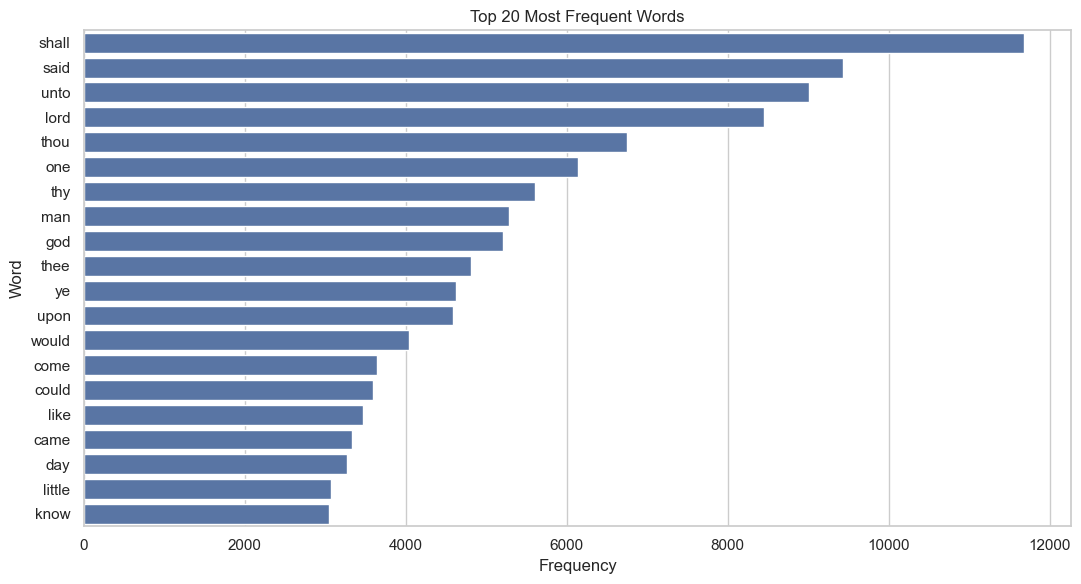

In [8]:
plt.figure(figsize=(11, 6))
sns.barplot(data=top_words_df, x="Frequency", y="Word")
plt.title("Top 20 Most Frequent Words")
plt.xlabel("Frequency")
plt.ylabel("Word")
plt.tight_layout()
plt.show()

## 6. Build Frequency-Based N-Gram Models

An n-gram predicts a word from a sequence of previous words.

- **Bigram model:** predicts the next word using one previous word.
- **Trigram model:** predicts the next word using the previous two words.

The model stores counts and ranks candidate next words by frequency.

In [9]:
# Build bigram and trigram counts
bigram_counts = Counter(ngrams(autocomplete_tokens, 2))
trigram_counts = Counter(ngrams(autocomplete_tokens, 3))

# Context -> next-word frequency mapping
bigram_next = defaultdict(Counter)
for (w1, w2), count in bigram_counts.items():
    bigram_next[w1][w2] += count

trigram_next = defaultdict(Counter)
for (w1, w2, w3), count in trigram_counts.items():
    trigram_next[(w1, w2)][w3] += count

print("Unique bigrams:", len(bigram_counts))
print("Unique trigrams:", len(trigram_counts))

Unique bigrams: 588451
Unique trigrams: 1414250


## 7. Autocomplete Functions

The functions below return the top 3 next-word predictions.

The **bigram approach** uses one context word.

The **trigram approach** uses the last two context words and therefore has more context. This usually helps specificity, although it can suffer from sparse/unseen contexts.

In [10]:
def predict_bigram(prefix, top_k=3):
    words = re.findall(r"[A-Za-z]+(?:'[A-Za-z]+)?", prefix.lower())
    if not words:
        return []

    context = words[-1]
    return bigram_next.get(context, Counter()).most_common(top_k)


def predict_trigram(prefix, top_k=3):
    words = re.findall(r"[A-Za-z]+(?:'[A-Za-z]+)?", prefix.lower())
    if len(words) < 2:
        return []

    context = (words[-2], words[-1])
    return trigram_next.get(context, Counter()).most_common(top_k)


def format_predictions(predictions):
    return [word for word, count in predictions]

## 8. Test Autocomplete on 10+ Input Prefixes

The test prefixes below are selected from common contexts in the Gutenberg corpus. For each prefix, the notebook displays the top 3 predictions from both models.

If a context is absent from a model, the result is reported as an unseen context instead of inventing a prediction.

In [11]:
test_prefixes = [
    "in the",
    "of the",
    "to the",
    "it was",
    "there was",
    "he was",
    "she was",
    "one of",
    "upon the",
    "when the",
    "as the",
    "with the"
]

autocomplete_rows = []

for prefix in test_prefixes:
    big = format_predictions(predict_bigram(prefix, 3))
    tri = format_predictions(predict_trigram(prefix, 3))

    autocomplete_rows.append({
        "Input Prefix": prefix,
        "Bigram Top 3": ", ".join(big) if big else "No prediction",
        "Trigram Top 3": ", ".join(tri) if tri else "No prediction"
    })

autocomplete_results = pd.DataFrame(autocomplete_rows)
display(autocomplete_results)

,Input Prefix,Bigram Top 3,Trigram Top 3
0,in the,"lord, king, son","land, midst, world"
1,of the,"lord, king, son","lord, house, earth"
2,to the,"lord, king, son","king, lord, house"
3,it was,"a, the, not","a, not, the"
4,there was,"a, the, not","a, no, not"
5,he was,"a, the, not","a, not, in"
6,she was,"a, the, not","not, a, very"
7,one of,"the, his, a","the, them, those"
8,upon the,"lord, king, son","earth, altar, mountains"
9,when the,"lord, king, son","lord, people, sun"


## 9. Autocomplete Precision and Recall

For a measurable test, we construct evaluation examples directly from the corpus.

For each selected context, the **actual next word in the corpus** is treated as the ground-truth word.

Because autocomplete returns a ranked list of three candidates:

- **Recall@3 = 1** if the actual next word appears anywhere in the top 3; otherwise 0.
- **Precision@3 = 1/3** when the correct next word appears in the top 3; otherwise 0.

The average over all evaluation examples gives overall Precision@3 and Recall@3.

This is a simple offline evaluation. Production autocomplete systems often use much larger test sets and metrics such as Top-K accuracy, MRR, keystroke savings, latency, and user acceptance rate.

In [12]:
# Create reproducible evaluation examples from the corpus.
# We use contexts that occur often enough to provide stable predictions.

bigram_eval = []
trigram_eval = []

for i in range(len(autocomplete_tokens) - 1):
    context = autocomplete_tokens[i]
    actual = autocomplete_tokens[i + 1]
    if context in bigram_next and len(bigram_next[context]) >= 3:
        bigram_eval.append((context, actual))

for i in range(len(autocomplete_tokens) - 2):
    context = (autocomplete_tokens[i], autocomplete_tokens[i + 1])
    actual = autocomplete_tokens[i + 2]
    if context in trigram_next and len(trigram_next[context]) >= 3:
        trigram_eval.append((context, actual))

# Sample a manageable but reproducible evaluation set.
random.shuffle(bigram_eval)
random.shuffle(trigram_eval)

bigram_eval = bigram_eval[:2000]
trigram_eval = trigram_eval[:2000]

def evaluate_autocomplete(eval_examples, model="bigram", k=3):
    hits = 0

    for context, actual in eval_examples:
        if model == "bigram":
            predictions = format_predictions(predict_bigram(context, k))
        else:
            predictions = format_predictions(
                predict_trigram(" ".join(context), k)
            )

        if actual in predictions:
            hits += 1

    n = len(eval_examples)
    recall_at_k = hits / n if n else 0
    precision_at_k = (hits / (n * k)) if n else 0

    return {
        "Examples": n,
        f"Precision@{k}": precision_at_k,
        f"Recall@{k}": recall_at_k
    }

bigram_metrics = evaluate_autocomplete(bigram_eval, "bigram", 3)
trigram_metrics = evaluate_autocomplete(trigram_eval, "trigram", 3)

autocomplete_metrics = pd.DataFrame([
    {"Model": "Bigram", **bigram_metrics},
    {"Model": "Trigram", **trigram_metrics}
])

display(autocomplete_metrics.round(4))

,Model,Examples,Precision@3,Recall@3
0,Bigram,2000,0.0922,0.2765
1,Trigram,2000,0.1412,0.4235


## 10. Autocomplete Algorithm Comparison

### Bigram
- Simple and fast.
- Requires less memory.
- Works well for frequent one-word contexts.
- Has limited context and can produce generic predictions.

### Trigram
- Uses two previous words.
- Captures more local context.
- Can provide more specific predictions.
- Requires more memory and has more unseen/sparse contexts.

The comparison above uses the same top-3 evaluation idea for both models.

## 11. Autocorrect Using Edit Distance

For autocorrection, we use `pyspellchecker`.

The library uses a word-frequency dictionary and edit-distance-based candidate generation. The misspelled input is compared against possible dictionary words and the most probable correction is returned.

The test below contains **20 deliberately misspelled words** with manually specified intended words.

In [13]:
spell = SpellChecker(language="en")

misspelled_pairs = [
    ("teh", "the"),
    ("recieve", "receive"),
    ("seperate", "separate"),
    ("definately", "definitely"),
    ("occured", "occurred"),
    ("becuase", "because"),
    ("adress", "address"),
    ("acheive", "achieve"),
    ("beleive", "believe"),
    ("enviroment", "environment"),
    (" goverment", "government"),
    ("langauge", "language"),
    ("wierd", "weird"),
    ("tommorow", "tomorrow"),
    ("succesful", "successful"),
    ("responsibilty", "responsibility"),
    ("experiance", "experience"),
    ("knowlege", "knowledge"),
    ("opurtunity", "opportunity"),
    ("pronounciation", "pronunciation")
]

# Clean accidental leading whitespace in the test case.
misspelled_pairs = [(wrong.strip(), correct) for wrong, correct in misspelled_pairs]

autocorrect_rows = []

for wrong, expected in misspelled_pairs:
    predicted = spell.correction(wrong)
    autocorrect_rows.append({
        "Misspelled": wrong,
        "Expected": expected,
        "Predicted": predicted,
        "Correct?": predicted == expected
    })

autocorrect_results = pd.DataFrame(autocorrect_rows)
display(autocorrect_results)

,Misspelled,Expected,Predicted,Correct?
0,teh,the,the,True
1,recieve,receive,receive,True
2,seperate,separate,separate,True
3,definately,definitely,definitely,True
4,occured,occurred,occurred,True
5,becuase,because,because,True
6,adress,address,dress,False
7,acheive,achieve,achieve,True
8,beleive,believe,believe,True
9,enviroment,environment,environment,True


## 12. Autocorrect Accuracy, Precision and Recall

For this deliberately constructed 20-word benchmark, a correction is considered successful when the predicted word exactly matches the intended word.

We report:

- **Accuracy:** correct corrections / all misspelled words.
- **Word-level Precision:** correct predicted corrections / all attempted corrections.
- **Word-level Recall:** correct corrections / all actual intended corrections.

Because every test case requires exactly one correction, Precision and Recall are numerically the same as accuracy for this small benchmark. In a real system, a larger labelled corpus should be used and additional metrics such as edit distance and top-k candidate accuracy should be considered.

In [14]:
tp = int(autocorrect_results["Correct?"].sum())
total = len(autocorrect_results)
incorrect = total - tp

accuracy = tp / total if total else 0
precision = tp / (tp + incorrect) if (tp + incorrect) else 0
recall = tp / total if total else 0

autocorrect_metrics = pd.DataFrame([{
    "Total Tests": total,
    "Correct Corrections (TP)": tp,
    "Incorrect Corrections": incorrect,
    "Accuracy": accuracy,
    "Precision": precision,
    "Recall": recall
}])

display(autocorrect_metrics.round(4))

,Total Tests,Correct Corrections (TP),Incorrect Corrections,Accuracy,Precision,Recall
0,20,19,1,0.95,0.95,0.95


## 13. Confusion Matrix for Autocorrect

The confusion matrix is represented as:

- **Correctly corrected:** predicted correction matches the intended word.
- **Incorrectly corrected:** prediction does not match the intended word.

For a single-label correction task, this binary view is more meaningful than a 21×21 word-by-word matrix because every spelling error has a different target word.

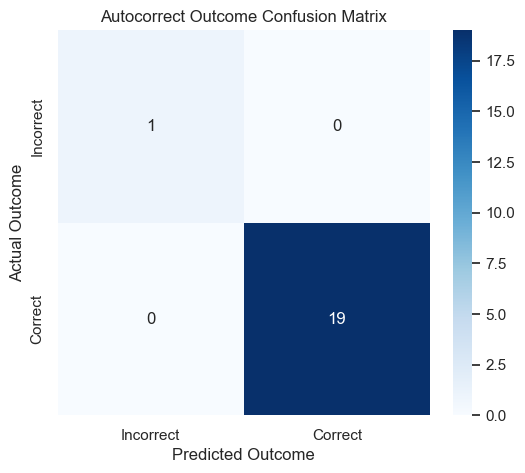

In [15]:
cm = np.array([
    [incorrect, 0],
    [0, tp]
])

plt.figure(figsize=(6, 5))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Incorrect", "Correct"],
    yticklabels=["Incorrect", "Correct"]
)
plt.title("Autocorrect Outcome Confusion Matrix")
plt.xlabel("Predicted Outcome")
plt.ylabel("Actual Outcome")
plt.show()

## 14. Edit Distance Analysis

To make the spelling-correction analysis more explicit, we calculate the Levenshtein edit distance between each misspelled word and:

1. The intended word.
2. The word predicted by `pyspellchecker`.

A lower distance indicates fewer character insertions, deletions, or substitutions are needed.

In [16]:
def levenshtein_distance(a, b):
    a = a.lower()
    b = b.lower()

    previous = list(range(len(b) + 1))

    for i, char_a in enumerate(a, start=1):
        current = [i]

        for j, char_b in enumerate(b, start=1):
            insertion = current[j - 1] + 1
            deletion = previous[j] + 1
            substitution = previous[j - 1] + (char_a != char_b)

            current.append(min(insertion, deletion, substitution))

        previous = current

    return previous[-1]


autocorrect_results["Distance to Expected"] = autocorrect_results.apply(
    lambda row: levenshtein_distance(row["Misspelled"], row["Expected"]),
    axis=1
)

autocorrect_results["Distance to Predicted"] = autocorrect_results.apply(
    lambda row: levenshtein_distance(row["Misspelled"], row["Predicted"]),
    axis=1
)

display(autocorrect_results)

,Misspelled,Expected,Predicted,Correct?,Distance to Expected,Distance to Predicted
0,teh,the,the,True,2,2
1,recieve,receive,receive,True,2,2
2,seperate,separate,separate,True,1,1
3,definately,definitely,definitely,True,1,1
4,occured,occurred,occurred,True,1,1
5,becuase,because,because,True,2,2
6,adress,address,dress,False,1,1
7,acheive,achieve,achieve,True,2,2
8,beleive,believe,believe,True,2,2
9,enviroment,environment,environment,True,1,1


## 15. Compare Autocomplete Approaches

The two autocomplete approaches are:

| Approach | Context | Main Advantage | Main Limitation |
|---|---|---|---|
| Bigram | Previous 1 word | Fast and lightweight | Limited context |
| Trigram | Previous 2 words | More contextual predictions | More sparse contexts and memory |

The metric comparison below provides an objective Top-3 evaluation.

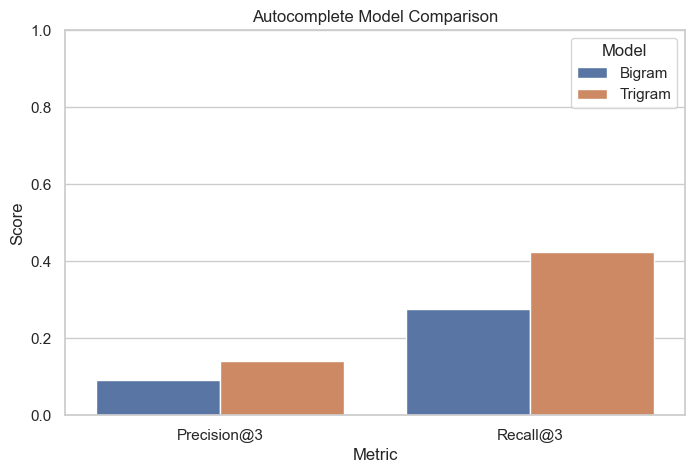

,Model,Examples,Precision@3,Recall@3
0,Bigram,2000,0.0922,0.2765
1,Trigram,2000,0.1412,0.4235


In [17]:
comparison = autocomplete_metrics.copy()

plt.figure(figsize=(8, 5))
metric_plot = comparison.melt(
    id_vars="Model",
    value_vars=["Precision@3", "Recall@3"],
    var_name="Metric",
    value_name="Score"
)

sns.barplot(data=metric_plot, x="Metric", y="Score", hue="Model")
plt.ylim(0, 1)
plt.title("Autocomplete Model Comparison")
plt.ylabel("Score")
plt.show()

display(comparison.round(4))

## 16. Limitations Compared with Production Systems

This implementation is useful for learning NLP fundamentals, but it is much simpler than production autocomplete and autocorrect systems such as Google Keyboard.

### Main limitations

1. **No deep semantic understanding**  
   Frequency-based n-grams mostly learn local word patterns. Neural language models can use much richer context.

2. **Limited context length**  
   A trigram sees only two previous words. Modern systems can use much longer context.

3. **No personalisation**  
   Production keyboards learn a user's vocabulary, writing style, names, frequently used phrases, and language preferences.

4. **No typo context modelling**  
   Real autocorrect considers surrounding words, sentence meaning, keyboard layout, and likely intended phrases.

5. **No keyboard proximity model**  
   Mobile keyboards can use nearby-key information to model common typing errors.

6. **Corpus bias**  
   Gutenberg books are literary/public-domain texts and may not represent modern chat, social media, technical language, or Indian English.

7. **Vocabulary limitations**  
   Names, slang, abbreviations, code, emojis, and newly created words may be missing from a traditional dictionary.

8. **No latency optimisation**  
   Production keyboards must generate predictions with extremely low latency on constrained devices.

9. **No online learning pipeline**  
   Production systems can update models and user-specific dictionaries over time.

10. **Evaluation is small**  
    The 20-word autocorrect benchmark is intentionally small for demonstration. A production evaluation would use thousands or millions of labelled examples and multiple languages/domains.

### Overall

This project demonstrates the fundamental ideas behind autocomplete and autocorrect, while production systems combine large-scale data, neural language models, personalised dictionaries, context awareness, keyboard signals, privacy-aware learning, and highly optimised inference.

## 17. Final Conclusion

This project implemented a complete NLP workflow for autocomplete and autocorrect.

### Key results produced by the notebook

- A large multi-book Gutenberg corpus was collected through NLTK.
- Text was tokenised, lowercased, and cleaned.
- Stopwords were removed for frequency analysis while retained for realistic autocomplete.
- Bigram and trigram frequency models were implemented.
- More than 10 autocomplete prefixes were tested with top-3 predictions.
- Autocomplete Precision@3 and Recall@3 were calculated.
- `pyspellchecker` was used for edit-distance-based spelling correction.
- 20 deliberately misspelled words were evaluated.
- Autocorrect accuracy, precision, and recall were calculated.
- Levenshtein distances were analysed.
- Top-20 word frequency and autocorrection outcome visualisations were created.
- Bigram and trigram approaches were compared.
- Limitations versus production keyboard systems were discussed.

### Key takeaway

**Frequency-based n-grams are simple, fast, and interpretable, but they have limited context and struggle with unseen patterns. Edit-distance-based autocorrection is useful for common spelling errors, but production systems require context, personalisation, modern language models, and much larger evaluation datasets.**